In [20]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

from pydantic import BaseModel, Field
from dotenv import load_dotenv
from datetime import datetime
import sqlite3
import uuid
import pandas as pd

load_dotenv()

True

In [21]:
class State(TypedDict):
    query: str
    category: str
    confidence: float
    sentiment: str
    response: str
    quality_score: float
    context: str
    ticket_id: str      
    ticket: dict


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

parser = StrOutputParser()

In [22]:
# ── Ticket database setup ─────────────────────────────────────────────────────
DB_PATH = "novatech_tickets.db"

def init_tickets_db():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS tickets (
            ticket_id     TEXT PRIMARY KEY,
            created_at    TEXT,
            category      TEXT,
            sentiment     TEXT,
            confidence    REAL,
            quality_score REAL,
            query         TEXT,
            response      TEXT,
            status        TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("Tickets database initialized ✅")

init_tickets_db()

Tickets database initialized ✅


In [12]:
def load_pdfs(pdf_paths: list) -> list:
    """Load all PDF files and return a flat list of documents."""
    all_docs = []
    for path in pdf_paths:
        loader = PyMuPDFLoader(path)
        docs = loader.load()
        all_docs.extend(docs)
        print(f"Loaded {len(docs)} pages from {path}")
    return all_docs


pdf_paths = [
    "./docs/novatech_technical_faq.pdf",
    "./docs/novatech_billing_faq.pdf",
    "./docs/novatech_general_faq.pdf",
]

docs = load_pdfs(pdf_paths)
print(f"\nTotal pages loaded: {len(docs)}")

Loaded 2 pages from ./docs/novatech_technical_faq.pdf
Loaded 2 pages from ./docs/novatech_billing_faq.pdf
Loaded 2 pages from ./docs/novatech_general_faq.pdf

Total pages loaded: 6


In [13]:
# Split into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)
chunks = splitter.split_documents(docs)
print(f"Total chunks created: {len(chunks)}")

# Build FAISS vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("\nKnowledge base built successfully!")

Total chunks created: 31

Knowledge base built successfully!


In [14]:
class QueryCategorySchema(BaseModel):
    category: Literal["Technical", "Billing", "General"] = Field(..., description="The category of the customer query: Technical, Billing, or General.")
    confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence score between 0.0 and 1.0 for the category classification.")

class QualityCheckSchema(BaseModel):
    quality_score: float = Field(..., ge=0.0, le=1.0, description="Quality score between 0.0 and 1.0. Score above 0.7 means the response is helpful and addresses the query.")
    feedback: str = Field(..., description="Brief feedback on why the response is or isn't helpful.")

class SentimentAnalysisSchema(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"] = Field(..., description="The sentiment of the customer query: Positive, Neutral, or Negative.")

def categorize(state: State) -> State:
    """Categorize the customer query into Technical, Billing, or General."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Categorize the following customer query into one of these categories: Technical, Billing, General. Also provide a confidence score between 0.0 and 1.0."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(QueryCategorySchema)
    result = chain.invoke({"query": state["query"]})
    return {
        "category": result.category,
        "confidence": result.confidence, 
    }

def analyze_sentiment(state: State) -> State:
    """Analyze the sentiment of the customer query as Positive, Neutral, or Negative."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Analyze the sentiment of the following customer query. Respond with either 'Positive', 'Neutral', or 'Negative'."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(SentimentAnalysisSchema)
    sentiment = chain.invoke({"query": state["query"]})
    return {"sentiment": sentiment.sentiment}

def handle_technical(state: State) -> State:
    """Provide a technical support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a technical support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}


def handle_billing(state: State) -> State:
    """Provide a billing support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a billing support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}


def handle_general(state: State) -> State:
    """Provide a general support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a general support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}

def escalate(state: State) -> State:
    """Escalate the query to a human agent due to negative sentiment."""
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}

def quality_check(state: State) -> State:
    """Check if the generated response is helpful and relevant to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a quality assurance reviewer for customer support responses.
Score the response on a scale of 0.0 to 1.0 based on:
- Does it directly address the query?
- Is it helpful and actionable?
- Is it professional and clear?"""),
        ("user", "Query: {query}\n\nResponse: {response}")
    ])
    chain = prompt | llm.with_structured_output(QualityCheckSchema)
    result = chain.invoke({
        "query": state["query"],
        "response": state["response"]
    })
    return {"quality_score": result.quality_score}


def regenerate_response(state: State) -> State:
    """Regenerate a better response if quality check failed."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """The previous response was not helpful enough.
Generate a better, more detailed and actionable response.
Category: {category}"""),
        ("user", "Query: {query}\n\nPrevious response that was not good enough: {response}")
    ])
    chain = prompt | llm | parser
    new_response = chain.invoke({
        "query": state["query"],
        "response": state["response"],
        "category": state["category"]
    })
    return {"response": new_response}

def route_query(state: State) -> str:
    """Route based on sentiment, then category, then confidence."""
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["confidence"] < 0.7:
        # ← if not confident enough, treat as general
        return "handle_general"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"
    
def route_quality(state: State) -> str:
    """Route based on quality score — regenerate if below threshold."""
    if state["quality_score"] < 0.7:
        return "regenerate_response"
    else:
        return END
    
def retrieve_context(state: State) -> State:
    """Retrieve relevant FAQ context for the query before generating a response."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(doc.page_content for doc in docs)
    return {"context": context}


def create_ticket(state: State) -> State:
    """Create a support ticket and save it to the database."""

    ticket_id = f"NVT-{str(uuid.uuid4())[:8].upper()}"
    created_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Determine status
    if state["sentiment"] == "Negative":
        status = "Escalated"
    elif state.get("quality_score", 1.0) < 0.7:
        status = "Regenerated"
    else:
        status = "Resolved"

    ticket = {
        "ticket_id":    ticket_id,
        "created_at":   created_at,
        "category":     state["category"],
        "sentiment":    state["sentiment"],
        "confidence":   state["confidence"],
        "quality_score": state.get("quality_score", 0.0),
        "query":        state["query"],
        "response":     state["response"],
        "status":       status,
    }

    # Save to SQLite
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        INSERT INTO tickets (
            ticket_id, created_at, category, sentiment,
            confidence, quality_score, query, response, status
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        ticket["ticket_id"], ticket["created_at"], ticket["category"],
        ticket["sentiment"], ticket["confidence"], ticket["quality_score"],
        ticket["query"], ticket["response"], ticket["status"]
    ))
    conn.commit()
    conn.close()

    print(f"Ticket created: {ticket_id} | Status: {status}")
    return {"ticket_id": ticket_id, "ticket": ticket}


def get_all_tickets():
    """Fetch all tickets from the database as a list of dicts."""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    cursor = conn.execute("SELECT * FROM tickets ORDER BY created_at DESC")
    tickets = [dict(row) for row in cursor.fetchall()]
    conn.close()
    return tickets

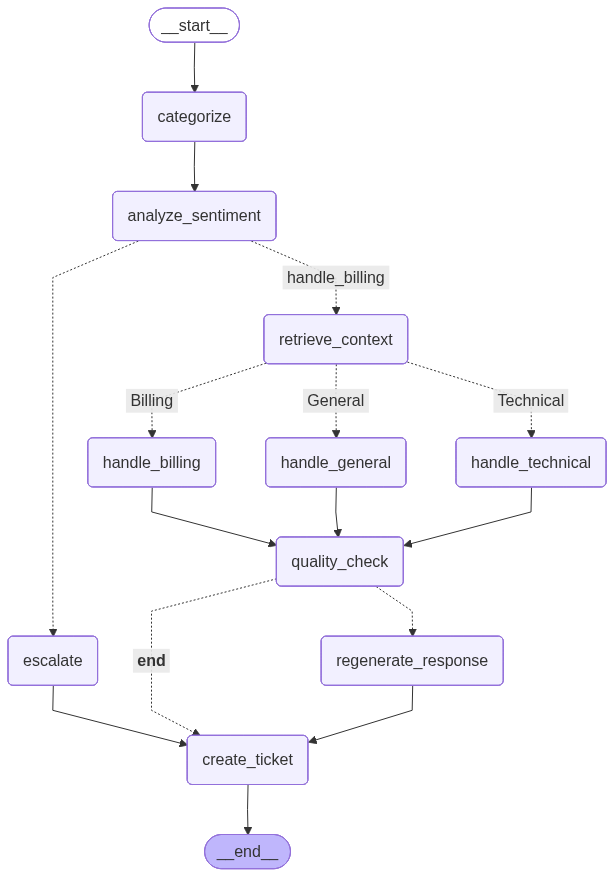

In [15]:
workflow = StateGraph(State)

workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)
workflow.add_node("quality_check", quality_check)
workflow.add_node("regenerate_response", regenerate_response)
workflow.add_node("create_ticket", create_ticket)    # ← new

workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "analyze_sentiment")
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "handle_technical": "retrieve_context",
        "handle_billing":   "retrieve_context",
        "handle_general":   "retrieve_context",
        "escalate":         "escalate",
    }
)
workflow.add_conditional_edges(
    "retrieve_context",
    lambda state: state["category"],
    {
        "Technical": "handle_technical",
        "Billing":   "handle_billing",
        "General":   "handle_general",
    }
)

workflow.add_edge("handle_technical", "quality_check")
workflow.add_edge("handle_billing",   "quality_check")
workflow.add_edge("handle_general",   "quality_check")

workflow.add_conditional_edges(
    "quality_check",
    route_quality,
    {
        "regenerate_response": "regenerate_response",
        END: "create_ticket",    # ← goes to ticket instead of END
    }
)
workflow.add_edge("regenerate_response", "create_ticket")  # ← changed
workflow.add_edge("escalate",            "create_ticket")  # ← changed
workflow.add_edge("create_ticket",       END)              # ← ticket is final

app = workflow.compile()
app

In [23]:
# Test 1 — Technical query
result = app.invoke({"query": "Is there a trial version of your software available?"})
print(f"Ticket ID: {result['ticket_id']}")
print(f"Status: {result['ticket']['status']}")
print(f"Response: {result['response']}")

print("\n--- All tickets in DB ---")

tickets = get_all_tickets()
df = pd.DataFrame(tickets)
print(df[["ticket_id", "created_at", "category", "sentiment", "status"]])

Ticket created: NVT-089ECDE7 | Status: Resolved
Ticket ID: NVT-089ECDE7
Status: Resolved
Response: Yes, NovaTech offers a 14-day free trial on the Pro plan with no credit card required. The trial includes full access to all Pro features, and you can invite team members immediately after setup.

--- All tickets in DB ---
      ticket_id           created_at category sentiment    status
0  NVT-089ECDE7  2026-04-15 04:31:27  General   Neutral  Resolved


In [24]:
print(result['quality_score'])

1.0
